### K-means Model

The goal is to be able to classify houses based on their area and income level.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import pickle

#### Loading Data

The data comes from the following URL: https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv

It is the known California Housing dataset, made with California's 1990 census.

In [30]:
df = pd.read_csv("/workspaces/crerov-intro-machine-learning/data/raw/housing.csv")
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


#### Descriptive Analysis

In [31]:
df.shape

(20640, 9)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [33]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### Data Cleaning

In [34]:
#As per exercise instructions, we only want to keep Latitude, Longitude and MedInc

df = df.drop(["HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "MedHouseVal"], axis=1)
df

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25
...,...,...,...
20635,1.5603,39.48,-121.09
20636,2.5568,39.49,-121.21
20637,1.7000,39.43,-121.22
20638,1.8672,39.43,-121.32


In [35]:
# Looking for duplicated data
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
20635    False
20636    False
20637    False
20638    False
20639    False
Length: 20640, dtype: bool

In [36]:
# Dropping duplicates if True
if df.duplicated().sum():
        df = df.drop_duplicates()
        
df

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25
...,...,...,...
20635,1.5603,39.48,-121.09
20636,2.5568,39.49,-121.21
20637,1.7000,39.43,-121.22
20638,1.8672,39.43,-121.32


##### Observations
Found and removed irrelevant columns and 5 duplicated rows.
All data is numerical, divided in 20635 rows and 3 columns.

#### Train/Test Split

In [37]:
from sklearn.model_selection import train_test_split
X = df
X_train, X_test = train_test_split(X, test_size = 0.2, random_state = 42)

X_train.head()

,MedInc,Latitude,Longitude
19985,3.1453,36.20,-119.31
11235,5.2384,33.81,-117.96
2271,3.5542,36.78,-119.80
8660,4.3594,33.85,-118.39
6250,3.4722,34.04,-117.98


In [38]:
# 1. Define Features (X)
X = df[["MedInc", "Latitude", "Longitude"]]

# 2. Split the data
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# 3. Initialize and fit the scaler
scaler = StandardScaler()

# 4. Transform the data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for consistency
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

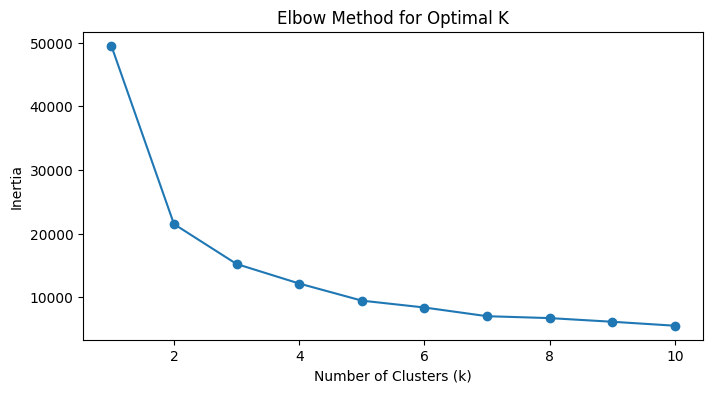

In [39]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

### Building K-Means Model

In [40]:
# Initialize and fit the model with 6 clusters using SCALED data
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X_train_scaled)

# Assign clusters to the ORIGINAL (unscaled) X_train for visualization
# This keeps the plot coordinates (Lat/Long) accurate
X_train["cluster"] = kmeans.labels_

# Extract y_train for the supervised model
y_train = kmeans.labels_

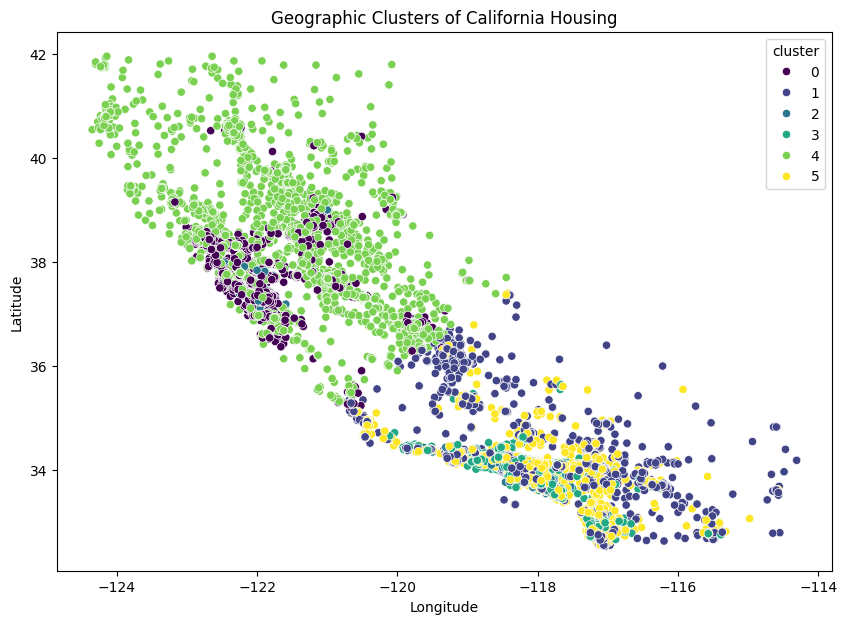

In [41]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X_train, x="Longitude", y="Latitude", hue="cluster", palette="viridis")
plt.title("Geographic Clusters of California Housing")
plt.show()

In [42]:

y_train = kmeans.labels_

y_test = kmeans.predict(X_test)

#### Predicting with the test set

In [43]:
# Predict using the scaled test data
y_test = kmeans.predict(X_test_scaled)

# Assign to unscaled X_test for visualization
X_test["cluster"] = y_test

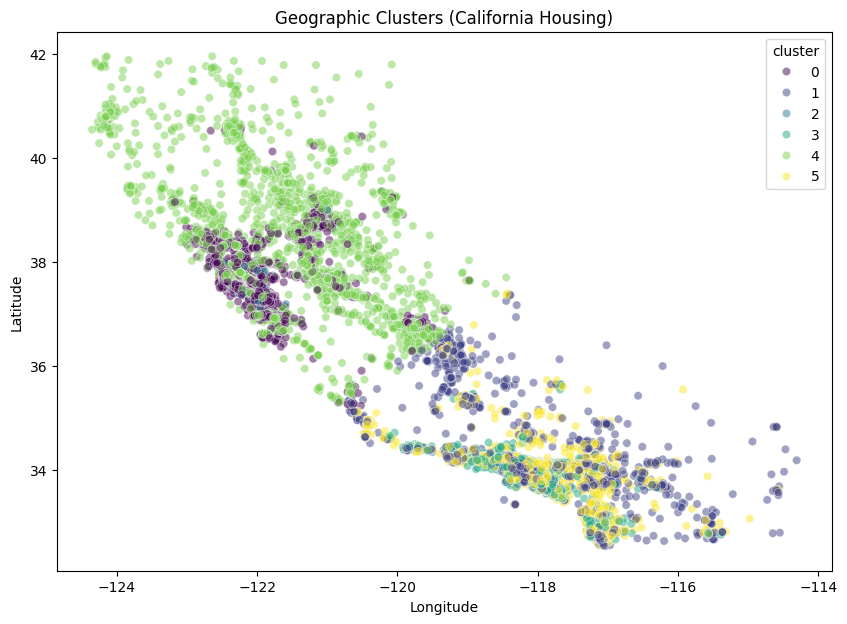

In [44]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X_train, x="Longitude", y="Latitude", hue="cluster", palette="viridis", alpha=0.5)
plt.title("Geographic Clusters (California Housing)")
plt.show()

We can see that the model has clssified the cluster pretty accurately.

#### Train a Decission Tree

I choose Decission Tree because it has rendered me the best result in previous exercises and allows me to not standarize the values.

In [45]:
# Initialize the classifier and the grid
dt_model = DecisionTreeClassifier(random_state=42)
param_grid = {'max_depth': [3, 5, 7, 10], 'criterion': ['gini', 'entropy']}

# Create GridSearchCV
grid = GridSearchCV(dt_model, param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

# Identify the final model
final_model = grid.best_estimator_


y_pred = final_model.predict(X_test_scaled)


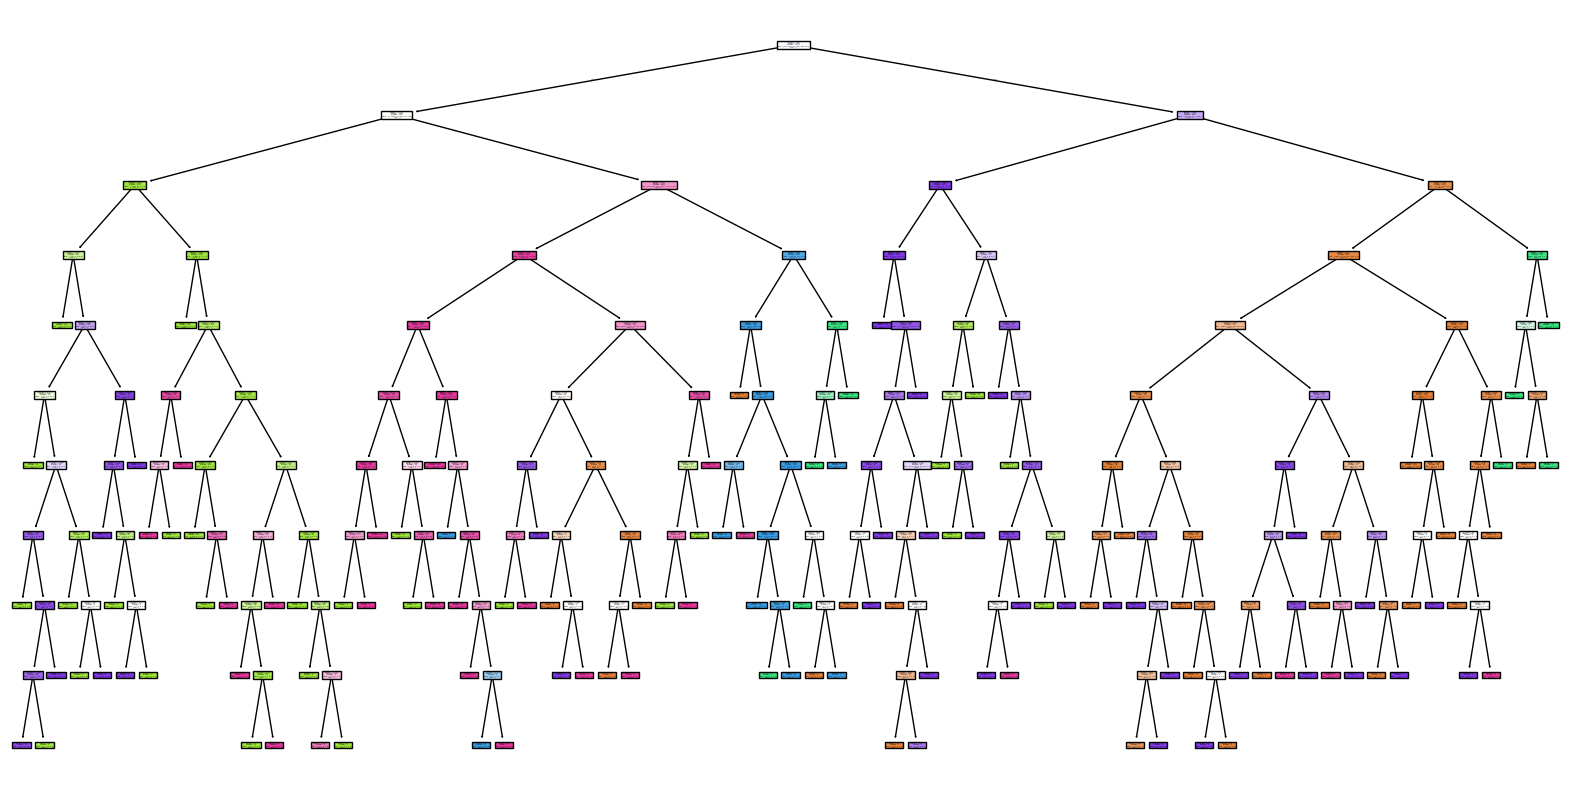

In [46]:
fig = plt.figure(figsize=(20,10))


tree.plot_tree(final_model, 
               feature_names=list(X_train.columns[:-1]), # Exclude 'cluster' column
               class_names=[str(i) for i in range(6)], 
               filled=True)

plt.show()

In [47]:

y_pred = final_model.predict(X_test_scaled)
y_pred

array([3, 4, 4, ..., 5, 5, 4], shape=(4127,), dtype=int32)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       583
           1       0.99      0.99      0.99      1013
           2       0.98      0.98      0.98        65
           3       1.00      0.99      1.00       386
           4       1.00      0.99      0.99      1078
           5       0.99      0.99      0.99      1002

    accuracy                           0.99      4127
   macro avg       0.99      0.99      0.99      4127
weighted avg       0.99      0.99      0.99      4127



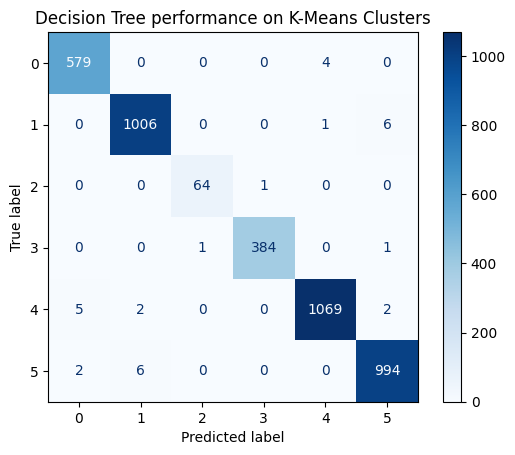

In [48]:

# 1. Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visual
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Decision Tree performance on K-Means Clusters")
plt.show()

#### Saving Models

In [49]:
# Save the Scaler (CRITICAL)
with open("/workspaces/crerov-intro-machine-learning/models/scaler.pk", "wb") as f:
    pickle.dump(scaler, f)

# Save the K-Means
with open("/workspaces/crerov-intro-machine-learning/models/Kmeans8.pk", "wb") as f:
    pickle.dump(kmeans, f)

# Save the Decision Tree
with open("/workspaces/crerov-intro-machine-learning/models/decisiontree8.pk", "wb") as f:
    pickle.dump(final_model, f)